# Pol II pools model with saturating reverse transitions

1. **Analytical argument.** We show that saturating the reverse transitions does not generically produce the input-insensitive ("buffered") behaviour seen in the data. In fact, in the saturated regime the output becomes a constant flux, which forces the elongating pool to collapse when Pol II is reduced. This is the opposite of buffering.
2. **Numerical fit.** We modify the original model to use Michaelis–Menten kinetics on all four transitions and refit to the same data. We then ask: does the fit prefer saturating reverse steps (low $K_m$), or does it drive $K_m$ to be large (first-order limit)?

## Alternative model equations

With Michaelis–Menten kinetics on every transition:

$$
\frac{dN}{dt} = \frac{V_{max,PN}P}{K_{m,PN} + P} + \frac{V_{max,EN}E}{K_{m,EN} + E} - \frac{V_{max,NP}N}{K_{m,NP} + N}
$$

$$
\frac{dP}{dt} = \frac{V_{max,NP}N}{K_{m,NP} + N} - \frac{V_{max,PN}P}{K_{m,PN} + P} - \frac{V_{max,PE}P}{K_{m,PE} + P}
$$

$$
\frac{dE}{dt} = \frac{V_{max,PE}P}{K_{m,PE} + P} - \frac{V_{max,EN}E}{K_{m,EN} + E}
$$

with the conservation constraint $N + P + E = T$.

The original model is the limit $K_{m,PN}, K_{m,EN} \to \infty$ with $V_{max,PN}/K_{m,PN} \to k_{PN}$ and $V_{max,EN}/K_{m,EN} \to k_{EN}$.

## 1. Analytical argument: saturating reverse steps cannot produce buffering

### 1.1 What "buffering" means quantitatively

Define the sensitivity of the elongating pool to total Pol II:

$$
S \;=\; \frac{d \ln E^*}{d \ln T}\bigg|_{T=1}
$$

where $E^*(T)$ is the steady-state elongating pool. Buffering means $S \ll 1$: a fractional change in $T$ produces a much smaller fractional change in $E$. The data give $S < 1$: output is relatively insensitive to input over a wide range of $T$.

### 1.2 Steady-state structure

At steady state, the E equation gives:

$$
\underbrace{\frac{V_{max,PE}P^*}{K_{m,PE} + P^*}}_{\text{flux } P\to E} \;=\; \underbrace{\frac{V_{max,EN}E^*}{K_{m,EN} + E^*}}_{\text{flux } E\to N}
$$

At steady state, the flux into E equals the flux out of E. The shape of $E^*(T)$ is determined entirely by how these two fluxes balance.

### 1.3 Two limiting regimes for the reverse transition

**Regime A (subsaturated, $E^* \ll K_{m,EN}$):** The reverse flux reduces to $(V_{max,EN}/K_{m,EN}) E^* \equiv k_{EN}^{\text{eff}} E^*$, which is just first-order. This is exactly the original model. No new behaviour.

**Regime B (saturated, $E^* \gg K_{m,EN}$):** The reverse flux becomes a constant $V_{max,EN}$, independent of $E^*$. The E equation becomes

$$
\frac{V_{max,PE}P^*}{K_{m,PE} + P^*} \;=\; V_{max,EN}.
$$

Because $E^*$ no longer appears, $P^*$ is fixed to a single value, independent of $T$:

$$
P^* \;=\; \frac{K_{m,PE} V_{max,EN}}{V_{max,PE} - V_{max,EN}}
$$

(assuming $V_{max,PE} > V_{max,EN}$, otherwise no steady state exists). 

Now consider the $P$ steady-state equation:

$$
\frac{V_{max,NP}N^*}{K_{m,NP} + N^*} \;=\; \frac{V_{max,PN}P^*}{K_{m,PN} + P^*} + \frac{V_{max,PE}P^*}{K_{m,PE} + P^*}.
$$

The right-hand side has two exit fluxes from $P$, but since $P^*$ is already fixed by the $E$ equation, both terms are completely determined. The left-hand side (influx from $N$) must therefore equal this fixed value, which makes $N^*$ independent of $T$ as well. With both $N^*$ and $P^*$ fixed, the conservation constraint $E^* = T - N^* - P^*$ means that $E^*$ absorbs all variation in $T$:

$$
\frac{dE^*}{dT} \approx 1.
$$

In terms of sensitivity, $S = \frac{d\ln E^*}{d\ln T} = \frac{T}{E^*} \cdot \frac{dE^*}{dT}$ (chain rule). Substituting $dE^*/dT \approx 1$ gives

$$
\boxed{\;S \approx \frac{T}{E^*}.\;}
$$

Since $E^*$ is only a *fraction* of $T$, we have $S > 1$. The elongating pool responds more sensitively than proportionally to changes in total Pol II, which is opposite to buffering.

### 1.4 What about partial saturation?

Between the two regimes, $E^*$ interpolates between linear-in-$T$ (regime B) and the buffered behaviour of the original model (regime A). Partial saturation of the reverse step can't do better than the first-order limit at producing buffering.

### 1.5 Intuition

Buffering arises from saturating the forward transitions ($N$-to-$P$ and $P$-to-$E$). When $N^* \gg K_{m,NP}$, the influx into the bound pool is approximately $V_{max,NP}$ regardless of $N^*$. The downstream pools are then buffered from variations in $T$ because the bottleneck supplying them is operating at its ceiling. This is the mechanism the original fit identified, and it is distinct from anything saturable termination can produce.

## 2. Numerical illustration of the analytical argument

Before refitting, we illustrate the analytical claim numerically: we sweep $K_{m,EN}$ from very large (first-order limit) to very small (saturation) at otherwise fixed parameters, and compute $E^*(T)$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, root
from scipy.linalg import norm

from matplotlib import colors as mcolors
from matplotlib.lines import Line2D

n_fitting_attempts_full = 50
n_fitting_attempts_minimal = 20

In [2]:
def steady_state_equations_alt(vars, T, params):
    """
    Steady-state equations for the alternative model with MM kinetics on ALL transitions.

    params: [Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Vmax_en, Km_en]

    The E→N V_max is fixed at 1.0 (analogous to k_en=1 in the original model) by absorbing
    it into the rescaling of the other rates. Here we let it float for generality.
    """
    N, P, E = vars
    Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Vmax_en, Km_en = params

    flux_np = Vmax_np * N / (Km_np + N)
    flux_pn = Vmax_pn * P / (Km_pn + P)
    flux_pe = Vmax_pe * P / (Km_pe + P)
    flux_en = Vmax_en * E / (Km_en + E)

    eq1 = N + P + E - T
    eq2 = flux_pe - flux_en
    eq3 = flux_np - flux_pn - flux_pe

    return [eq1, eq2, eq3]


def get_steady_state_alt(T, params, tolerance=1e-8):
    """Robust solver for the alternative steady-state system."""
    initial_guesses = [
        [T * 0.5, T * 0.3, T * 0.2],
        [T * 0.7, T * 0.2, T * 0.1],
        [T * 0.2, T * 0.6, T * 0.2],
        [T * 0.1, T * 0.2, T * 0.7],
        [T * 0.8, T * 0.15, T * 0.05],
        [T * 0.33, T * 0.33, T * 0.34],
    ]
    solutions = []
    for guess in initial_guesses:
        for method in ["hybr", "lm"]:
            try:
                result = root(
                    steady_state_equations_alt,
                    guess,
                    args=(T, params),
                    method=method,
                    options={"xtol": tolerance},
                )
                if result.success:
                    N, P, E = result.x
                    if (
                        N >= -tolerance
                        and P >= -tolerance
                        and E >= -tolerance
                        and abs(N + P + E - T) < tolerance
                    ):
                        solutions.append((result.x, norm(result.fun)))
                        break
            except Exception:
                continue
    if not solutions:
        return {
            "solution": [np.nan, np.nan, np.nan],
            "converged": False,
            "stable": False,
        }
    best = min(solutions, key=lambda x: x[1])
    return {
        "solution": list(best[0]),
        "converged": True,
        "stable": True,
        "residual_norm": best[1],
    }

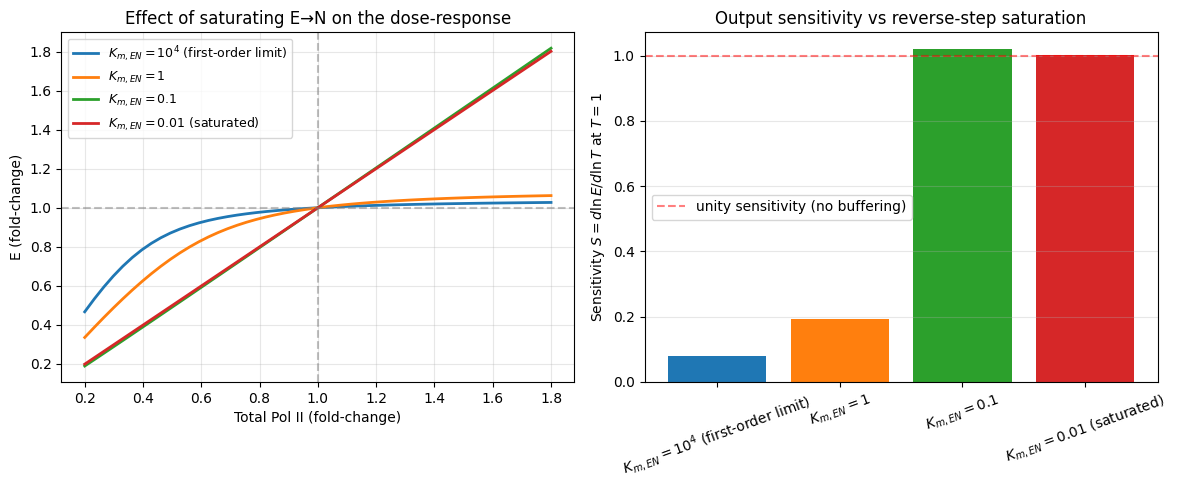

In [3]:
# Sweep Km_en across orders of magnitude to demonstrate the regimes.
# Hold the effective first-order rate k_en = Vmax_en/Km_en fixed at 1.0 in the
# large-Km (first-order) limit, then ask what happens as we shrink Km_en into the
# saturated regime.

# Load parameters from the original model fit
params_df = pd.read_csv("buffering_params.csv")
params_orig = params_df["value"].values  # [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]

k_pn_eff = params_orig[0]
Vmax_pe = params_orig[1]
Km_pe = params_orig[2]
Vmax_np = params_orig[3]
Km_np = params_orig[4]
k_en_eff = 1.0

# Hold Km_pn very large (so P→N stays first-order in this sweep); vary Km_en only.
Km_pn_large = 1e4
Vmax_pn_large = k_pn_eff * Km_pn_large

Km_en_values = [1e4, 1.0, 0.1, 0.01]  # large → first-order limit, small → saturated
labels = [
    r"$K_{m,EN}=10^4$ (first-order limit)",
    r"$K_{m,EN}=1$",
    r"$K_{m,EN}=0.1$",
    r"$K_{m,EN}=0.01$ (saturated)",
]

T_range = np.linspace(0.2, 1.8, 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for Km_en, label in zip(Km_en_values, labels):
    Vmax_en = k_en_eff * Km_en
    params_alt = [
        Vmax_pn_large,
        Km_pn_large,
        Vmax_pe,
        Km_pe,
        Vmax_np,
        Km_np,
        Vmax_en,
        Km_en,
    ]
    E_vals = []
    for T in T_range:
        res = get_steady_state_alt(T, params_alt)
        E_vals.append(res["solution"][2] if res["converged"] else np.nan)
    E_vals = np.array(E_vals)

    # Normalise to T=1 to get fold-change
    res1 = get_steady_state_alt(1.0, params_alt)
    E_base = res1["solution"][2] if res1["converged"] else np.nan
    axes[0].plot(T_range, E_vals / E_base, label=label, linewidth=2)

    # Local sensitivity dlnE/dlnT at T=1
    eps = 0.01
    r_lo = get_steady_state_alt(1.0 - eps, params_alt)
    r_hi = get_steady_state_alt(1.0 + eps, params_alt)
    if r_lo["converged"] and r_hi["converged"] and res1["converged"]:
        E_lo, E_hi = r_lo["solution"][2], r_hi["solution"][2]
        S = (np.log(E_hi) - np.log(E_lo)) / (np.log(1 + eps) - np.log(1 - eps))
        axes[1].bar(label, S)

axes[0].axhline(1, color="grey", linestyle="--", alpha=0.5)
axes[0].axvline(1, color="grey", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Total Pol II (fold-change)")
axes[0].set_ylabel("E (fold-change)")
axes[0].set_title("Effect of saturating E→N on the dose-response")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(
    1.0,
    color="red",
    linestyle="--",
    alpha=0.5,
    label="unity sensitivity (no buffering)",
)
axes[1].set_ylabel(r"Sensitivity $S = d\ln E / d\ln T$ at $T=1$")
axes[1].set_title("Output sensitivity vs reverse-step saturation")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Fitting the alternative model to the data

If saturating reverse transitions were a viable explanation for the observed buffering, fitting the alternative model to the same data should yield finite, well-determined $K_{m,PN}$ and $K_{m,EN}$ in the saturated range. Conversely, if the analytical argument is right, the fit should push $K_{m,PN}$ and $K_{m,EN}$ to *large* values (the first-order limit), confirming that the data prefer first-order reverse transitions.

In [4]:
try:
    # Load T and E fold-change data from CSV files

    # --- Biallelic degron ---
    data_path_1 = "../data/mACPOLR2A_pSer2PolII_8hours_Values_ByExperiment.csv"
    exp_data_1 = pd.read_csv(data_path_1)
    control_data_1 = exp_data_1[
        (exp_data_1["AUXIN_CONCENTRATION_nM"] == 0)
        & (exp_data_1["TIME_IN_AUXIN_HRS"] == 0)
    ]
    T_baseline_1 = control_data_1["Total_PolII_F12_Normed"].mean()
    E_baseline_1 = control_data_1["pSer2_PolII_3E10_Normed"].mean()
    T_fc_1 = (exp_data_1["Total_PolII_F12_Normed"] / T_baseline_1).values
    E_fc_1 = (exp_data_1["pSer2_PolII_3E10_Normed"] / E_baseline_1).values
    dataset_1 = np.array(["mACPOLR2A_biallelic"] * len(T_fc_1))

    # --- mACmChPOLR2A Active PolII ---
    data_path_2 = "../data/mACmChPOLR2A_ActivePolII_Values_ByExperiment.csv"
    exp_data_2 = pd.read_csv(data_path_2)
    control_data_2 = exp_data_2[exp_data_2["TIME_IN_AUXIN_H"] == 0]
    T_baseline_2 = control_data_2["Total_PolII_F12_Normed"].mean()
    E_baseline_2 = control_data_2["pSer2_PolII_3E10_Normed"].mean()
    T_fc_2 = (exp_data_2["Total_PolII_F12_Normed"] / T_baseline_2).values
    E_fc_2 = (exp_data_2["pSer2_PolII_3E10_Normed"] / E_baseline_2).values
    dataset_2 = np.array(["mACmChPOLR2A"] * len(T_fc_2))

    # --- ARMC5 ---
    data_path_3A = "../data/ARMC5_mAC_Clone5A_TotalEU_Values_ByExperiment.csv"
    data_path_3B = "../data/ARMC5_mAC_Clone5A1_Phospho_Values_ByExperiment.csv"
    exp_data_3A = pd.read_csv(data_path_3A)
    exp_data_3B = pd.read_csv(data_path_3B)

    # Average across experiments at each timepoint, then merge on timepoint
    T_by_time = (
        exp_data_3A.groupby("TIME_IN_AUXIN_H")["Total_PolII_F12_Normed"]
        .agg(["mean", "std"])
        .reset_index()
    )
    E_by_time = (
        exp_data_3B.groupby("TIME_IN_AUXIN_H")["pSer2_PolII_3E10_Normed"]
        .agg(["mean", "std"])
        .reset_index()
    )
    exp_data_3 = T_by_time.merge(E_by_time, on="TIME_IN_AUXIN_H", suffixes=("_T", "_E"))

    control_3 = exp_data_3[exp_data_3["TIME_IN_AUXIN_H"] == 0]
    T_baseline_3 = control_3["mean_T"].mean()
    E_baseline_3 = control_3["mean_E"].mean()

    T_fc_3 = (exp_data_3["mean_T"] / T_baseline_3).values
    E_fc_3 = (exp_data_3["mean_E"] / E_baseline_3).values
    E_fc_3_sd = (exp_data_3["std_E"] / E_baseline_3).values
    dataset_3 = np.array(["ARMC5"] * len(T_fc_3))

    T_E_fc = np.concatenate([T_fc_1, T_fc_2, T_fc_3])
    E_fc_data = np.concatenate([E_fc_1, E_fc_2, E_fc_3])
    E_datasets = np.concatenate([dataset_1, dataset_2, dataset_3])

    # --- Bound fraction (FRAP) ---
    bound_fraction_mCh_mACmCh_path = "../data/mACmChPOLR2A_FRAP_Amounts_perday.csv"
    bf1 = pd.read_csv(bound_fraction_mCh_mACmCh_path)
    bf1 = bf1[bf1["CONDITION"] != "mACmChPOLR2A VEH"]
    T_bound_1 = bf1["RELATIVE_TOTAL"].values / 100.0
    bound_frac_1 = bf1["BOUND_FRACTION"].values
    bf_dataset_1 = np.array(["mACmChPOLR2A"] * len(T_bound_1))

    bf2 = pd.read_csv("../data/mACmChPOLR2A_mClover3_FRAP_Amounts_perday.csv")
    bf2 = bf2[bf2["CONDITION"] == "mACPOLR2A VEH"].rename(
        columns={"BOUND": "BOUND_FRACTION"}
    )
    T_bound_2 = bf2["RELATIVE_TOTAL"].values / 100.0
    bound_frac_2 = bf2["BOUND_FRACTION"].values / 100.0
    bf_dataset_2 = np.array(["mACPOLR2A_biallelic"] * len(T_bound_2))

    bf3 = pd.read_csv("../data/mACPOLR2A_biallelic_FRAP_Bound_Free_RelativeTotal.csv")
    T_bound_3 = bf3["RELATIVE_TOTAL"].values / 100.0
    bound_frac_3 = bf3["BOUND_FRACTION"].values
    bf_dataset_3 = np.array(["mACPOLR2A_biallelic"] * len(T_bound_3))

    bf4 = pd.read_csv("../data/mChPOLR2A_FRAP_Scrambled_ARMC5_amounts_per_day.csv")
    bf4 = bf4[
        (bf4["CONDITION"] == "ARMC5 VEHICLE")
        | (bf4["CONDITION"] == "SCRAMBLED VEHICLE")
    ]
    T_bound_4 = bf4["RELATIVE_TOTAL"].values / 100.0
    bound_frac_4 = bf4["BOUND_FRACTION"].values
    bf_dataset_4 = np.array(["ARMC5"] * len(T_bound_4))

    T_bound_fraction = np.concatenate([T_bound_1, T_bound_2, T_bound_3, T_bound_4])
    bound_fraction_data = np.concatenate(
        [bound_frac_1, bound_frac_2, bound_frac_3, bound_frac_4]
    )
    bf_datasets = np.concatenate(
        [bf_dataset_1, bf_dataset_2, bf_dataset_3, bf_dataset_4]
    )

    # --- Paused fold-change (manual) ---
    T_P_fc = np.array([0.738, 1.0, 1.51])
    P_fc_data = np.array([0.909, 1.0, 1.45])
    P_datasets = np.array(["ChIP-seq"] * len(T_P_fc))

    print("Data loaded successfully.")
    print(f"E fold-change: {len(T_E_fc)} points")
    print(f"Bound fraction: {len(T_bound_fraction)} points")
    print(f"P fold-change: {len(T_P_fc)} points")

except FileNotFoundError as e:
    print(f"Data file not found: {e.filename}.")
    raise

Data loaded successfully.
E fold-change: 54 points
Bound fraction: 33 points
P fold-change: 3 points


In [5]:
def objective_function_alt(params, apply_constraint=True, constraint_weight=100.0):
    """
    Objective for the alternative model with MM kinetics on ALL transitions.

    params: [Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Vmax_en, Km_en]

    Identifiability: the overall flux scale is set by Vmax_en. To match the original
    parameterisation we fix Vmax_en = 1.0 and fit the remaining 7 parameters.
    """
    Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Km_en = params
    Vmax_en = 1.0  # fixed for identifiability (matches k_en=1 in the original model)

    # Bound check
    if any(p <= 0 for p in params):
        return 1e6
    if Vmax_pn > 1e6 or Km_pn > 1e6 or Vmax_pe > 50 or Km_pe > 50:
        return 1e6
    if Vmax_np > 50 or Km_np > 50 or Km_en > 1e6:
        return 1e6

    full_params = [Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Vmax_en, Km_en]

    total_residual = 0.0
    n_data_points = 0

    # Baseline at T=1
    base = get_steady_state_alt(1.0, full_params)
    if not base["converged"]:
        return 1e6
    N_base, P_base, E_base = base["solution"]
    if E_base <= 0 or P_base <= 0:
        return 1e6

    # 1. E fold-change
    E_preds = []
    for T_val in T_E_fc:
        r = get_steady_state_alt(T_val, full_params)
        if not r["converged"]:
            return 1e6
        E_preds.append(r["solution"][2] / E_base)
    E_preds = np.array(E_preds)

    # Inverse-variance weights for ARMC5 averaged points
    # Add small epsilon to avoid division by zero if SD happens to be 0
    epsilon = 1e-6
    armc5_weights = 1.0 / (E_fc_3_sd**2 + epsilon)

    # Normalise so the mean ARMC5 weight equals 3.0
    # (upweighting ARMC5 data to match actual replicate number)
    armc5_weights = armc5_weights / armc5_weights.mean() * 3.0

    weights = np.concatenate(
        [
            np.ones(len(T_fc_1)),
            np.ones(len(T_fc_2)),
            armc5_weights,
        ]
    )
    E_residuals = weights * (E_preds - E_fc_data) ** 2
    total_residual += np.sum(E_residuals)
    n_data_points += np.sum(weights)

    # 2. Bound fraction
    bf_preds = []
    for T_val in T_bound_fraction:
        r = get_steady_state_alt(T_val, full_params)
        if not r["converged"]:
            return 1e6
        N, P, E = r["solution"]
        bf_preds.append((P + E) / T_val if T_val > 0 else 0)
    total_residual += np.sum((np.array(bf_preds) - bound_fraction_data) ** 2)
    n_data_points += len(bf_preds)

    # 3. P fold-change
    P_preds = []
    for T_val in T_P_fc:
        r = get_steady_state_alt(T_val, full_params)
        if not r["converged"]:
            return 1e6
        P_preds.append(r["solution"][1] / P_base)
    total_residual += np.sum((np.array(P_preds) - P_fc_data) ** 2)
    n_data_points += len(P_preds)

    # 4. Flux ratio constraint at T=1 (P→N flux = 4× P→E flux)
    if apply_constraint:
        flux_pn = Vmax_pn * P_base / (Km_pn + P_base)
        flux_pe = Vmax_pe * P_base / (Km_pe + P_base)
        total_residual += constraint_weight * (flux_pn - 4 * flux_pe) ** 2

    return total_residual / n_data_points if n_data_points > 0 else 1e6


def _solutions_are_distinct(p1, p2, rel_tol=0.05):
    """Two parameter vectors count as distinct if any parameter differs by more than rel_tol
    in log-space (i.e. more than ~5% relative difference)."""
    p1 = np.asarray(p1)
    p2 = np.asarray(p2)
    log_diff = np.abs(np.log10(np.maximum(p1, 1e-12)) - np.log10(np.maximum(p2, 1e-12)))
    return np.any(log_diff > rel_tol)


def fit_alt_model(
    n_attempts=200,
    apply_constraint=True,
    constraint_weight=100.0,
    seed=42,
    n_top=10,
    distinctness_tol=0.05,
):
    """Fit the alternative model with multi-start, returning the top-N distinct solutions.

    A solution is 'distinct' from another if at least one parameter differs by more than
    distinctness_tol (default 5%) in log10 space. This filters out near-duplicate minima
    while keeping genuinely different local minima.
    """
    # [Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Km_en]
    bounds = [
        (0.01, 1e5),  # Vmax_pn
        (1e-3, 1e5),  # Km_pn
        (0.01, 20),  # Vmax_pe
        (1e-3, 10),  # Km_pe
        (0.01, 20),  # Vmax_np
        (1e-3, 10),  # Km_np
        (1e-3, 1e5),  # Km_en
    ]

    np.random.seed(seed)
    all_successful = []

    for attempt in range(n_attempts):
        x0 = []
        for lo, hi in bounds:
            if hi / lo > 100:
                x0.append(10 ** np.random.uniform(np.log10(lo), np.log10(hi)))
            else:
                x0.append(np.random.uniform(lo, hi))
        try:
            result = minimize(
                objective_function_alt,
                x0,
                args=(apply_constraint, constraint_weight),
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": 2000},
            )
            if result.success:
                all_successful.append(result)
        except Exception:
            continue

    if not all_successful:
        return None, [], []

    # Sort by cost
    all_successful.sort(key=lambda r: r.fun)

    # Build distinct list
    distinct = [all_successful[0]]
    for r in all_successful[1:]:
        if all(_solutions_are_distinct(r.x, d.x, distinctness_tol) for d in distinct):
            distinct.append(r)
        if len(distinct) >= n_top:
            break

    return distinct[0], distinct, all_successful


print("Fitting full M-M model ...")
print(
    f"Running multi-start with {n_fitting_attempts_full} attempts; returning top-10 distinct minima.\n"
)
best_alt, top_alt, all_alt = fit_alt_model(n_attempts=n_fitting_attempts_full, n_top=10)

if best_alt is None:
    print("All fitting attempts failed.")
else:
    print(f"{'='*78}")
    print(f"Top-{len(top_alt)} distinct local minima (sorted by cost):")
    print(f"{'='*78}")
    print(
        f"{'rank':>4} | {'cost':>10} | {'Vmax_pn':>10} | {'Km_pn':>10} | "
        f"{'Vmax_pe':>10} | {'Km_pe':>10} | {'Vmax_np':>10} | {'Km_np':>10} | {'Km_en':>10}"
    )
    print("-" * 78)
    for i, r in enumerate(top_alt, 1):
        Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Km_en = r.x
        print(
            f"{i:>4} | {r.fun:>10.6f} | {Vmax_pn:>10.4g} | {Km_pn:>10.4g} | "
            f"{Vmax_pe:>10.4g} | {Km_pe:>10.4g} | {Vmax_np:>10.4g} | {Km_np:>10.4g} | {Km_en:>10.4g}"
        )

    print()
    print(
        f"Total successful runs: {len(all_alt)}, distinct minima found: {len(top_alt)}"
    )
    print()
    # Check how many of the top minima have reverse-step Km values consistent with
    # the first-order regime. A step is "first-order" if it is unsaturated across
    # the operating range of its substrate. We evaluate saturation = X/(Km+X) at
    # the steady-state substrate levels for T in [0.3, 1.6] and require that the
    # MAX saturation across this range stays below a threshold.
    FIRST_ORDER_THRESHOLD = 0.2
    SATURATED_THRESHOLD = 0.8
    T_check = np.linspace(0.3, 1.6, 20)

    def reverse_step_saturations(r):
        """Return (max_sat_pn, max_sat_en) across the operating T range."""
        Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Km_en = r.x
        full_p = [Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, 1.0, Km_en]
        sat_pn_vals, sat_en_vals = [], []
        for T in T_check:
            ss = get_steady_state_alt(T, full_p)
            if ss["converged"]:
                N, P, E = ss["solution"]
                sat_pn_vals.append(P / (Km_pn + P))
                sat_en_vals.append(E / (Km_en + E))
        if not sat_pn_vals:
            return np.nan, np.nan
        return max(sat_pn_vals), max(sat_en_vals)

    def verdict(s):
        if s < FIRST_ORDER_THRESHOLD:
            return "first-order"
        if s > SATURATED_THRESHOLD:
            return "saturated"
        return "intermediate"

    # Compute once, reuse for counts and table
    sat_results = [reverse_step_saturations(r) for r in top_alt]

    n_first_order_reverse = sum(
        1
        for (sp, se) in sat_results
        if sp < FIRST_ORDER_THRESHOLD and se < FIRST_ORDER_THRESHOLD
    )
    n_saturated_reverse = sum(
        1
        for (sp, se) in sat_results
        if sp > SATURATED_THRESHOLD or se > SATURATED_THRESHOLD
    )

    print(f"Of the top-{len(top_alt)} distinct minima:")
    print(
        f"  - {n_first_order_reverse}/{len(top_alt)} have BOTH reverse steps first-order"
        f" (max saturation < {FIRST_ORDER_THRESHOLD:.0%} across T∈[0.3, 1.6])"
    )
    print(
        f"  - {n_saturated_reverse}/{len(top_alt)} have at least one reverse step saturated"
        f" (max saturation > {SATURATED_THRESHOLD:.0%} across T∈[0.3, 1.6])"
    )
    print()
    print(
        f"  {'rank':>4} | {'max sat P→N':>12} | {'max sat E→N':>12} | {'P→N regime':>14} | {'E→N regime':>14}"
    )
    print(f"  {'-'*68}")
    for i, (r, (max_sat_pn, max_sat_en)) in enumerate(zip(top_alt, sat_results), 1):
        print(
            f"  {i:>4} | {max_sat_pn:>12.3f} | {max_sat_en:>12.3f} | "
            f"{verdict(max_sat_pn):>14} | {verdict(max_sat_en):>14}"
        )

    # Report best fit details
    print()
    print(f"Best fit (final cost {best_alt.fun:.6f}):")
    print()

    Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Km_en = best_alt.x

    print(f"  Vmax_pn = {Vmax_pn:.4g}")
    print(f"  Km_pn   = {Km_pn:.4g}")
    print(f"  Vmax_pe = {Vmax_pe:.4g}")
    print(f"  Km_pe   = {Km_pe:.4g}")
    print(f"  Vmax_np = {Vmax_np:.4g}")
    print(f"  Km_np   = {Km_np:.4g}")
    print(f"  Vmax_en = 1.0 (fixed)")
    print(f"  Km_en   = {Km_en:.4g}")
    print()
    print(f"  Effective k_pn = Vmax_pn/Km_pn = {Vmax_pn/Km_pn:.4g}")
    print(f"  Effective k_en = Vmax_en/Km_en = {1.0/Km_en:.4g}")
    print()
    print(
        f"  (Original model values: k_pn=5.44, k_en=1.0; absolute scale differs because"
    )
    print(f"   the alternative model fixes Vmax_en rather than k_en.)")

Fitting full M-M model ...
Running multi-start with 50 attempts; returning top-10 distinct minima.

Top-10 distinct local minima (sorted by cost):
rank |       cost |    Vmax_pn |      Km_pn |    Vmax_pe |      Km_pe |    Vmax_np |      Km_np |      Km_en
------------------------------------------------------------------------------
   1 |   0.001646 |      62.15 |      352.2 |    0.01133 |    0.02251 |     0.0933 |     0.3066 |      33.12
   2 |   0.001648 |      69.66 |      200.8 |    0.02286 |    0.02223 |     0.1835 |     0.3022 |      16.22
   3 |   0.001650 |       1348 |       2665 |    0.03356 |    0.02202 |     0.2685 |     0.3018 |      10.92
   4 |   0.001651 |       5322 |       7689 |    0.04582 |     0.0216 |     0.3662 |     0.3013 |      7.903
   5 |   0.001651 |      983.4 |       1220 |    0.05333 |     0.0214 |     0.4261 |     0.3009 |      6.738
   6 |   0.001651 |        294 |      336.8 |    0.05777 |    0.02134 |     0.4612 |     0.3004 |      6.189
   7 |   0.

## 4. Diagnostic: how saturated are the reverse steps in the best fit?

We compute, at the best-fit parameters, the *saturation level* of each reverse transition over the experimental range of $T$. Saturation level = $X^* / (K_m + X^*)$ — close to 1 means saturated, close to 0 means subsaturated (first-order).

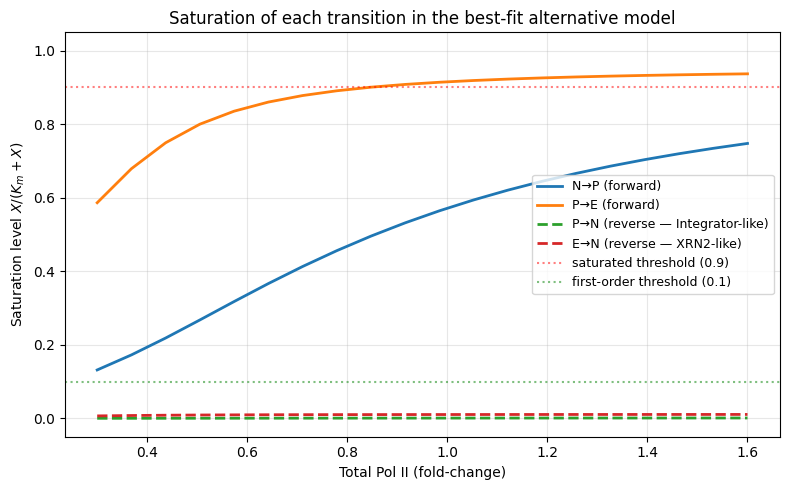


Interpretation:
  P→N reverse saturation at T=1: 0.001
  E→N reverse saturation at T=1: 0.010
  N→P forward saturation at T=1: 0.565
  P→E forward saturation at T=1: 0.914


In [6]:
if best_alt is not None:
    full_params = list(best_alt.x[:6]) + [1.0, best_alt.x[6]]
    # full_params order: Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Vmax_en, Km_en
    Vmax_pn, Km_pn, Vmax_pe, Km_pe, Vmax_np, Km_np, Vmax_en, Km_en = full_params

    T_vals = np.linspace(0.3, 1.6, 20)
    sat_pn, sat_en, sat_np, sat_pe = [], [], [], []
    for T in T_vals:
        r = get_steady_state_alt(T, full_params)
        if r["converged"]:
            N, P, E = r["solution"]
            sat_pn.append(P / (Km_pn + P))
            sat_en.append(E / (Km_en + E))
            sat_np.append(N / (Km_np + N))
            sat_pe.append(P / (Km_pe + P))
        else:
            sat_pn.append(np.nan)
            sat_en.append(np.nan)
            sat_np.append(np.nan)
            sat_pe.append(np.nan)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(T_vals, sat_np, label="N→P (forward)", linewidth=2)
    ax.plot(T_vals, sat_pe, label="P→E (forward)", linewidth=2)
    ax.plot(
        T_vals,
        sat_pn,
        label="P→N (reverse — Integrator-like)",
        linewidth=2,
        linestyle="--",
    )
    ax.plot(
        T_vals, sat_en, label="E→N (reverse — XRN2-like)", linewidth=2, linestyle="--"
    )
    ax.axhline(
        0.9, color="red", linestyle=":", alpha=0.5, label="saturated threshold (0.9)"
    )
    ax.axhline(
        0.1,
        color="green",
        linestyle=":",
        alpha=0.5,
        label="first-order threshold (0.1)",
    )
    ax.set_xlabel("Total Pol II (fold-change)")
    ax.set_ylabel("Saturation level $X / (K_m + X)$")
    ax.set_title("Saturation of each transition in the best-fit alternative model")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="center right")
    plt.tight_layout()
    plt.show()

    print("\nInterpretation:")
    print(f"  P→N reverse saturation at T=1: {sat_pn[len(T_vals)//2]:.3f}")
    print(f"  E→N reverse saturation at T=1: {sat_en[len(T_vals)//2]:.3f}")
    print(f"  N→P forward saturation at T=1: {sat_np[len(T_vals)//2]:.3f}")
    print(f"  P→E forward saturation at T=1: {sat_pe[len(T_vals)//2]:.3f}")

## 5. Comparison with the original (first-order reverse) model

Side-by-side fit quality.

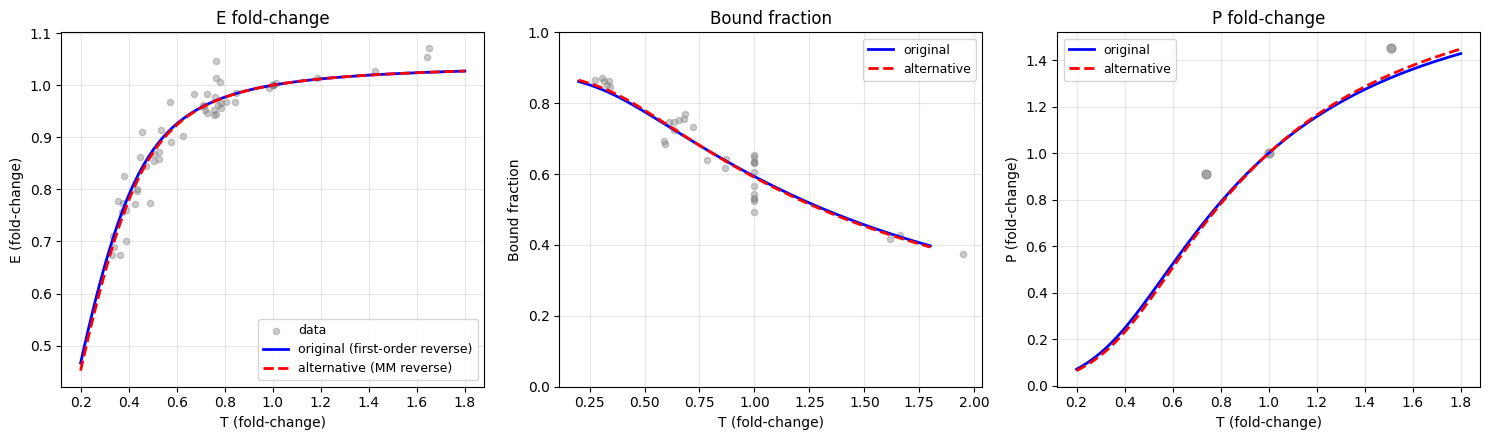


Final cost — alternative model: 0.001646
Final cost — original model: 0.001673


In [7]:
# Re-fit the original model for direct comparison
def steady_state_orig(vars, T, params):
    N, P, E = vars
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = params
    k_en = 1.0
    return [
        N + P + E - T,
        Vmax_pe * P / (Km_pe + P) - k_en * E,
        Vmax_np * N / (Km_np + N) - k_pn * P - Vmax_pe * P / (Km_pe + P),
    ]


def get_ss_orig(T, params, tol=1e-8):
    guesses = [
        [T * 0.5, T * 0.3, T * 0.2],
        [T * 0.7, T * 0.2, T * 0.1],
        [T * 0.2, T * 0.6, T * 0.2],
        [T * 0.1, T * 0.2, T * 0.7],
        [T * 0.33, T * 0.33, T * 0.34],
    ]
    for g in guesses:
        try:
            res = root(steady_state_orig, g, args=(T, params), method="hybr")
            if res.success:
                N, P, E = res.x
                if N > -tol and P > -tol and E > -tol and abs(N + P + E - T) < tol:
                    return {"solution": list(res.x), "converged": True}
        except Exception:
            continue
    return {"solution": [np.nan] * 3, "converged": False}


# Best-fit parameters from the original notebook (loaded from CSV)
params_csv = pd.read_csv("buffering_params.csv")
params_orig = params_csv["value"].values  # [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]


# Calculate original model cost for comparison
def compute_original_cost(params):
    """Compute cost for the original model (first-order reverse steps)."""
    total_residual = 0.0
    n_data_points = 0

    # Baseline at T=1
    base = get_ss_orig(1.0, params)
    if not base["converged"]:
        return np.nan
    N_base, P_base, E_base = base["solution"]
    if E_base <= 0 or P_base <= 0:
        return np.nan

    # E fold-change
    E_preds = []
    for T_val in T_E_fc:
        r = get_ss_orig(T_val, params)
        if not r["converged"]:
            return np.nan
        E_preds.append(r["solution"][2] / E_base)
    E_preds = np.array(E_preds)

    # Apply same weighting as alternative model
    epsilon = 1e-6
    armc5_weights = 1.0 / (E_fc_3_sd**2 + epsilon)
    armc5_weights = armc5_weights / armc5_weights.mean() * 3.0
    weights = np.concatenate(
        [np.ones(len(T_fc_1)), np.ones(len(T_fc_2)), armc5_weights]
    )
    E_residuals = weights * (E_preds - E_fc_data) ** 2
    total_residual += np.sum(E_residuals)
    n_data_points += np.sum(weights)

    # Bound fraction
    bf_preds = []
    for T_val in T_bound_fraction:
        r = get_ss_orig(T_val, params)
        if not r["converged"]:
            return np.nan
        N, P, E = r["solution"]
        bf_preds.append((P + E) / T_val if T_val > 0 else 0)
    total_residual += np.sum((np.array(bf_preds) - bound_fraction_data) ** 2)
    n_data_points += len(bf_preds)

    # P fold-change
    P_preds = []
    for T_val in T_P_fc:
        r = get_ss_orig(T_val, params)
        if not r["converged"]:
            return np.nan
        P_preds.append(r["solution"][1] / P_base)
    total_residual += np.sum((np.array(P_preds) - P_fc_data) ** 2)
    n_data_points += len(P_preds)

    return total_residual / n_data_points if n_data_points > 0 else np.nan


original_cost = compute_original_cost(params_orig)

# Generate predictions across T range
T_plot = np.linspace(0.2, 1.8, 80)

# Original model predictions
orig_N, orig_P, orig_E = [], [], []
base_o = get_ss_orig(1.0, params_orig)["solution"]
for T in T_plot:
    r = get_ss_orig(T, params_orig)
    if r["converged"]:
        orig_N.append(r["solution"][0])
        orig_P.append(r["solution"][1])
        orig_E.append(r["solution"][2])
    else:
        orig_N.append(np.nan)
        orig_P.append(np.nan)
        orig_E.append(np.nan)
orig_E = np.array(orig_E)
orig_P = np.array(orig_P)
orig_N = np.array(orig_N)

# Alternative model predictions
if best_alt is not None:
    full_params = list(best_alt.x[:6]) + [1.0, best_alt.x[6]]
    alt_N, alt_P, alt_E = [], [], []
    base_a = get_steady_state_alt(1.0, full_params)["solution"]
    for T in T_plot:
        r = get_steady_state_alt(T, full_params)
        if r["converged"]:
            alt_N.append(r["solution"][0])
            alt_P.append(r["solution"][1])
            alt_E.append(r["solution"][2])
        else:
            alt_N.append(np.nan)
            alt_P.append(np.nan)
            alt_E.append(np.nan)
    alt_E = np.array(alt_E)
    alt_P = np.array(alt_P)
    alt_N = np.array(alt_N)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    # E fold-change
    axes[0].scatter(T_E_fc, E_fc_data, alpha=0.4, color="grey", s=20, label="data")
    axes[0].plot(
        T_plot, orig_E / base_o[2], "b-", lw=2, label="original (first-order reverse)"
    )
    axes[0].plot(
        T_plot, alt_E / base_a[2], "r--", lw=2, label="alternative (MM reverse)"
    )
    axes[0].set_xlabel("T (fold-change)")
    axes[0].set_ylabel("E (fold-change)")
    axes[0].set_title("E fold-change")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # Bound fraction
    axes[1].scatter(
        T_bound_fraction, bound_fraction_data, alpha=0.4, color="grey", s=20
    )
    axes[1].plot(T_plot, (orig_P + orig_E) / T_plot, "b-", lw=2, label="original")
    axes[1].plot(T_plot, (alt_P + alt_E) / T_plot, "r--", lw=2, label="alternative")
    axes[1].set_xlabel("T (fold-change)")
    axes[1].set_ylabel("Bound fraction")
    axes[1].set_title("Bound fraction")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0, 1)

    # P fold-change
    axes[2].scatter(T_P_fc, P_fc_data, alpha=0.7, color="grey", s=40)
    axes[2].plot(T_plot, orig_P / base_o[1], "b-", lw=2, label="original")
    axes[2].plot(T_plot, alt_P / base_a[1], "r--", lw=2, label="alternative")
    axes[2].set_xlabel("T (fold-change)")
    axes[2].set_ylabel("P (fold-change)")
    axes[2].set_title("P fold-change")
    axes[2].legend(fontsize=9)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nFinal cost — alternative model: {best_alt.fun:.6f}")
    print(f"Final cost — original model: {original_cost:.6f}")

## 7. Supplementary figure

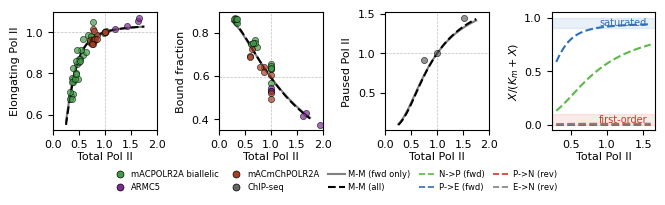


Supplementary figure saved to:
  supp_fig_termination_kinetics.pdf
  supp_fig_termination_kinetics.png

Model comparison:
  Original model cost: 0.001673
  Alternative model cost: 0.001646


In [8]:
assert best_alt is not None, "Run the fit cell first."

# Define dataset colors (matching buffering_range.ipynb)
dataset_colors = {
    "mACPOLR2A_biallelic": "#419c46",
    "ARMC5": "#7c2c91",
    "mACmChPOLR2A": "#a73f23",
    "ChIP-seq": "#666666",
}

# Define transition colors
xkcd_medium_blue = mcolors.XKCD_COLORS["xkcd:medium blue"]
color_pe = xkcd_medium_blue  # P->E forward
color_np = "#5bba47"  # N->P forward
color_pn = "#cf3727"  # P->N reverse
color_en = "grey"  # E->N reverse

# Load original model parameters
params_csv = pd.read_csv("buffering_params.csv")
params_orig = params_csv["value"].values  # [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]

# Compute original model cost for the label
orig_model_cost = compute_original_cost(params_orig)

# Prepare alternative model parameters
full_params_best = list(best_alt.x[:6]) + [1.0, best_alt.x[6]]
Vmax_pn_b, Km_pn_b, Vmax_pe_b, Km_pe_b, Vmax_np_b, Km_np_b, Vmax_en_b, Km_en_b = (
    full_params_best
)

# Generate predictions along T range
T_plot = np.linspace(0.25, 1.75, 100)

# Original model predictions
orig_E, orig_P, orig_N = [], [], []
base_o = get_ss_orig(1.0, params_orig)["solution"]
for T in T_plot:
    r = get_ss_orig(T, params_orig)
    if r["converged"]:
        orig_N.append(r["solution"][0])
        orig_P.append(r["solution"][1])
        orig_E.append(r["solution"][2])
    else:
        orig_N.append(np.nan)
        orig_P.append(np.nan)
        orig_E.append(np.nan)
orig_E = np.array(orig_E)
orig_P = np.array(orig_P)
orig_N = np.array(orig_N)
orig_bound = (orig_P + orig_E) / T_plot

# Alternative model predictions
alt_E, alt_P, alt_N = [], [], []
base_a = get_steady_state_alt(1.0, full_params_best)["solution"]
for T in T_plot:
    r = get_steady_state_alt(T, full_params_best)
    if r["converged"]:
        alt_N.append(r["solution"][0])
        alt_P.append(r["solution"][1])
        alt_E.append(r["solution"][2])
    else:
        alt_N.append(np.nan)
        alt_P.append(np.nan)
        alt_E.append(np.nan)
alt_E = np.array(alt_E)
alt_P = np.array(alt_P)
alt_N = np.array(alt_N)
alt_bound = (alt_P + alt_E) / T_plot

# Saturation levels for each transition (alternative model)
T_vals = np.linspace(0.3, 1.6, 40)
sat_pn, sat_en, sat_np, sat_pe = [], [], [], []
for T in T_vals:
    r = get_steady_state_alt(T, full_params_best)
    if r["converged"]:
        N, P, E = r["solution"]
        sat_pn.append(P / (Km_pn_b + P))
        sat_en.append(E / (Km_en_b + E))
        sat_np.append(N / (Km_np_b + N))
        sat_pe.append(P / (Km_pe_b + P))
    else:
        for L in (sat_pn, sat_en, sat_np, sat_pe):
            L.append(np.nan)

# Create figure with wider panel gaps and one compact shared legend row
cm_to_inch = 1 / 2.54
fig = plt.figure(figsize=(17 * cm_to_inch, 5.0 * cm_to_inch))
gs = fig.add_gridspec(1, 4, wspace=0.6, left=0.08, right=0.98, top=0.95, bottom=0.35)

# Set font size globally for this figure
plt.rcParams.update({"font.size": 8})

# -----------------------------------------------------------------------
# Panel A: E fold-change
# -----------------------------------------------------------------------
axA = fig.add_subplot(gs[0, 0])

# Plot data colored by dataset
for dataset_name, color in dataset_colors.items():
    mask = E_datasets == dataset_name
    if np.any(mask):
        axA.scatter(
            T_E_fc[mask],
            E_fc_data[mask],
            color=color,
            s=20,
            alpha=0.7,
            edgecolors="black",
            linewidths=0.5,
            zorder=3,
        )

# Plot model fits
axA.plot(
    T_plot,
    orig_E / base_o[2],
    color="grey",
    linewidth=1.5,
    zorder=2,
)
axA.plot(
    T_plot,
    alt_E / base_a[2],
    color="black",
    linestyle="--",
    linewidth=1.5,
    zorder=2,
)

axA.axhline(1, color="grey", linestyle="--", alpha=0.5, linewidth=0.5, zorder=1)
axA.axvline(1, color="grey", linestyle="--", alpha=0.5, linewidth=0.5, zorder=1)
axA.set_xlabel("Total Pol II", fontsize=8, labelpad=1)
axA.set_ylabel("Elongating Pol II", fontsize=8)
axA.tick_params(labelsize=8)
axA.locator_params(axis="x", nbins=4)
axA.locator_params(axis="y", nbins=4)

# -----------------------------------------------------------------------
# Panel B: Bound fraction
# -----------------------------------------------------------------------
axB = fig.add_subplot(gs[0, 1])

# Plot data colored by dataset
for dataset_name, color in dataset_colors.items():
    mask = bf_datasets == dataset_name
    if np.any(mask):
        axB.scatter(
            T_bound_fraction[mask],
            bound_fraction_data[mask],
            color=color,
            s=20,
            alpha=0.7,
            edgecolors="black",
            linewidths=0.5,
            zorder=3,
        )

# Plot model fits
axB.plot(
    T_plot,
    orig_bound,
    color="grey",
    linewidth=1.5,
    zorder=2,
)
axB.plot(
    T_plot,
    alt_bound,
    color="black",
    linestyle="--",
    linewidth=1.5,
    zorder=2,
)

axB.axhline(
    orig_bound[np.argmin(np.abs(T_plot - 1.0))],
    color="grey",
    linestyle="--",
    alpha=0.5,
    linewidth=0.5,
    zorder=1,
)
axB.axvline(1, color="grey", linestyle="--", alpha=0.5, linewidth=0.5, zorder=1)
axB.set_xlabel("Total Pol II", fontsize=8, labelpad=1)
axB.set_ylabel("Bound fraction", fontsize=8)
axB.tick_params(labelsize=8)
axB.locator_params(axis="x", nbins=4)
axB.locator_params(axis="y", nbins=4)

# -----------------------------------------------------------------------
# Panel C: P fold-change
# -----------------------------------------------------------------------
axC = fig.add_subplot(gs[0, 2])

# Plot data colored by dataset
for dataset_name, color in dataset_colors.items():
    mask = P_datasets == dataset_name
    if np.any(mask):
        axC.scatter(
            T_P_fc[mask],
            P_fc_data[mask],
            color=color,
            s=20,
            alpha=0.7,
            edgecolors="black",
            linewidths=0.5,
            zorder=3,
        )

# Plot model fits
axC.plot(
    T_plot,
    orig_P / base_o[1],
    color="grey",
    linewidth=1.5,
    zorder=2,
)
axC.plot(
    T_plot,
    alt_P / base_a[1],
    color="black",
    linestyle="--",
    linewidth=1.5,
    zorder=2,
)

axC.axhline(1, color="grey", linestyle="--", alpha=0.5, linewidth=0.5, zorder=1)
axC.axvline(1, color="grey", linestyle="--", alpha=0.5, linewidth=0.5, zorder=1)
axC.set_xlabel("Total Pol II", fontsize=8, labelpad=1)
axC.set_ylabel("Paused Pol II", fontsize=8)
axC.tick_params(labelsize=8)
axC.locator_params(axis="x", nbins=4)
axC.locator_params(axis="y", nbins=4)

# -----------------------------------------------------------------------
# Panel D: Saturation diagnostic for alternative model
# -----------------------------------------------------------------------
axD = fig.add_subplot(gs[0, 3])

axD.plot(
    T_vals,
    sat_np,
    color=color_np,
    linewidth=1.5,
    linestyle="--",
)
axD.plot(
    T_vals,
    sat_pe,
    color=color_pe,
    linewidth=1.5,
    linestyle="--",
)
axD.plot(
    T_vals,
    sat_pn,
    color=color_pn,
    linewidth=1.5,
    linestyle="--",
)
axD.plot(
    T_vals,
    sat_en,
    color=color_en,
    linewidth=1.5,
    linestyle="--",
)
axD.axhspan(0.9, 1.0, color=color_pe, alpha=0.10)
axD.axhspan(0.0, 0.1, color=color_pn, alpha=0.10)
axD.text(1.55, 0.95, "saturated", fontsize=7, color=color_pe, ha="right", va="center")
axD.text(1.55, 0.05, "first-order", fontsize=7, color=color_pn, ha="right", va="center")
axD.set_xlabel("Total Pol II", fontsize=8, labelpad=1)
axD.set_ylabel(r"$X / (K_m + X)$", fontsize=8, labelpad=2)
axD.set_ylim(-0.05, 1.05)
axD.tick_params(labelsize=8)
axD.locator_params(axis="x", nbins=4)
axD.locator_params(axis="y", nbins=4)

# One compact shared legend row below all panels
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=dataset_colors["mACPOLR2A_biallelic"],
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=5,
        label="mACPOLR2A biallelic",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=dataset_colors["ARMC5"],
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=5,
        label="ARMC5",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=dataset_colors["mACmChPOLR2A"],
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=5,
        label="mACmChPOLR2A",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=dataset_colors["ChIP-seq"],
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=5,
        label="ChIP-seq",
    ),
    Line2D([0], [0], color="grey", linewidth=1.5, label=f"M-M (fwd only)"),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1.5,
        linestyle="--",
        label=f"M-M (all)",
    ),
    Line2D([0], [0], color=color_np, linewidth=1.2, label="N->P (fwd)", linestyle="--"),
    Line2D([0], [0], color=color_pe, linewidth=1.2, label="P->E (fwd)", linestyle="--"),
    Line2D([0], [0], color=color_pn, linewidth=1.2, linestyle="--", label="P->N (rev)"),
    Line2D([0], [0], color=color_en, linewidth=1.2, linestyle="--", label="E->N (rev)"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=5,
    fontsize=6,
    frameon=False,
    columnspacing=1.0,
    handletextpad=0.4,
)

axA.set_xlim(0.0, 2.0)
axB.set_xlim(0.0, 2.0)
axC.set_xlim(0.0, 2.0)


plt.savefig("supp_fig_termination_kinetics.pdf")
plt.savefig("supp_fig_termination_kinetics.png", dpi=200)
plt.show()

print("\nSupplementary figure saved to:")
print("  supp_fig_termination_kinetics.pdf")
print("  supp_fig_termination_kinetics.png")
print(f"\nModel comparison:")
print(f"  Original model cost: {orig_model_cost:.6f}")
print(f"  Alternative model cost: {best_alt.fun:.6f}")

## 9. First-order forward reactions, MM reverse

The previous sections fit a generalised model with Michaelis-Menten kinetics on all four transitions. The fit drove the reverse-step Michaelis constants into the unsaturated regime, we now confirm that reverse-step Michaelis-Menten kinetics alone cannot lead to buffering by removing the possibility of Michaelis-Menten kinetics on the forward reactions.

### Equations

$$
\frac{dN}{dt} = \frac{V_{max,PN}P}{K_{m,PN} + P} + \frac{V_{max,EN}E}{K_{m,EN} + E} - k_{NP}N
$$

$$
\frac{dP}{dt} = k_{NP}N - \frac{V_{max,PN}P}{K_{m,PN} + P} - k_{PE}P
$$

$$
\frac{dE}{dt} = k_{PE}P - \frac{V_{max,EN}E}{K_{m,EN} + E}
$$

Six free parameters: $k_{NP}$, $k_{PE}$, $V_{max,PN}$, $K_{m,PN}$, $K_{m,EN}$ (with $V_{max,EN} = 1$ fixed for scale).


In [9]:
def steady_state_equations_strict(vars, T, params):
    """Forward first-order, reverse MM.
    params: [k_np, k_pe, Vmax_pn, Km_pn, Vmax_en, Km_en]
    """
    N, P, E = vars
    k_np, k_pe, Vmax_pn, Km_pn, Vmax_en, Km_en = params
    flux_np = k_np * N
    flux_pe = k_pe * P
    flux_pn = Vmax_pn * P / (Km_pn + P)
    flux_en = Vmax_en * E / (Km_en + E)
    return [N + P + E - T, flux_pe - flux_en, flux_np - flux_pn - flux_pe]


def get_ss_strict(T, params, tol=1e-8):
    guesses = [
        [T * 0.5, T * 0.3, T * 0.2],
        [T * 0.7, T * 0.2, T * 0.1],
        [T * 0.2, T * 0.6, T * 0.2],
        [T * 0.1, T * 0.2, T * 0.7],
        [T * 0.8, T * 0.15, T * 0.05],
        [T * 0.33, T * 0.33, T * 0.34],
    ]
    solutions = []
    for g in guesses:
        for method in ["hybr", "lm"]:
            try:
                res = root(
                    steady_state_equations_strict,
                    g,
                    args=(T, params),
                    method=method,
                    options={"xtol": tol},
                )
                if res.success:
                    N, P, E = res.x
                    if (
                        N >= -tol
                        and P >= -tol
                        and E >= -tol
                        and abs(N + P + E - T) < tol
                    ):
                        solutions.append((res.x, norm(res.fun)))
                        break
            except Exception:
                continue
    if not solutions:
        return {"solution": [np.nan] * 3, "converged": False}
    best = min(solutions, key=lambda x: x[1])
    return {"solution": list(best[0]), "converged": True}


def objective_strict(params, apply_constraint=True, constraint_weight=100.0):
    """params: [k_np, k_pe, Vmax_pn, Km_pn, Km_en]; Vmax_en fixed at 1.0."""
    k_np, k_pe, Vmax_pn, Km_pn, Km_en = params
    Vmax_en = 1.0
    if any(p <= 0 for p in params):
        return 1e6
    full_params = [k_np, k_pe, Vmax_pn, Km_pn, Vmax_en, Km_en]

    base = get_ss_strict(1.0, full_params)
    if not base["converged"]:
        return 1e6
    N_b, P_b, E_b = base["solution"]
    if E_b <= 0 or P_b <= 0:
        return 1e6

    total = 0.0
    n = 0

    E_preds = []
    for T_val in T_E_fc:
        r = get_ss_strict(T_val, full_params)
        if not r["converged"]:
            return 1e6
        E_preds.append(r["solution"][2] / E_b)
    total += np.sum((np.array(E_preds) - E_fc_data) ** 2)
    n += len(E_preds)

    bf_preds = []
    for T_val in T_bound_fraction:
        r = get_ss_strict(T_val, full_params)
        if not r["converged"]:
            return 1e6
        _, P, E = r["solution"]
        bf_preds.append((P + E) / T_val if T_val > 0 else 0)
    total += np.sum((np.array(bf_preds) - bound_fraction_data) ** 2)
    n += len(bf_preds)

    P_preds = []
    for T_val in T_P_fc:
        r = get_ss_strict(T_val, full_params)
        if not r["converged"]:
            return 1e6
        P_preds.append(r["solution"][1] / P_b)
    total += np.sum((np.array(P_preds) - P_fc_data) ** 2)
    n += len(P_preds)

    if apply_constraint:
        flux_pn = Vmax_pn * P_b / (Km_pn + P_b)
        flux_pe = k_pe * P_b
        total += constraint_weight * (flux_pn - 4 * flux_pe) ** 2

    return total / n if n > 0 else 1e6


def fit_strict(n_attempts=200, seed=42, n_top=10, distinctness_tol=0.05):
    """Multi-start fit returning top-N distinct minima."""
    bounds = [
        (0.01, 50),  # k_np
        (0.01, 50),  # k_pe
        (0.01, 1e5),  # Vmax_pn
        (1e-3, 1e5),  # Km_pn
        (1e-3, 1e5),  # Km_en
    ]
    np.random.seed(seed)
    all_ok = []
    for _ in range(n_attempts):
        x0 = []
        for lo, hi in bounds:
            if hi / lo > 100:
                x0.append(10 ** np.random.uniform(np.log10(lo), np.log10(hi)))
            else:
                x0.append(np.random.uniform(lo, hi))
        try:
            r = minimize(
                objective_strict,
                x0,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": 2000},
            )
            if r.success:
                all_ok.append(r)
        except Exception:
            continue
    if not all_ok:
        return None, [], []
    all_ok.sort(key=lambda r: r.fun)

    def distinct(p1, p2, tol=distinctness_tol):
        p1, p2 = np.asarray(p1), np.asarray(p2)
        ld = np.abs(np.log10(np.maximum(p1, 1e-12)) - np.log10(np.maximum(p2, 1e-12)))
        return np.any(ld > tol)

    distincts = [all_ok[0]]
    for r in all_ok[1:]:
        if all(distinct(r.x, d.x) for d in distincts):
            distincts.append(r)
        if len(distincts) >= n_top:
            break
    return distincts[0], distincts, all_ok


print("Fitting model (forward first-order, reverse MM)...")
print(
    f"Running multi-start with {n_fitting_attempts_minimal} attempts; returning top-10 distinct minima.\n"
)
best_strict, top_strict, all_strict = fit_strict()

if best_strict is None:
    print("FIT FAILED — could not find any valid local minimum.")
else:
    print(f"{'='*92}")
    print(
        f"Top {len(top_strict)} distinct local minima for the STRICT model "
        f"(forward first-order, reverse MM):"
    )
    print(f"{'='*92}")
    print(
        f"{'rank':>4} | {'cost':>10} | {'k_np':>10} | {'k_pe':>10} | "
        f"{'Vmax_pn':>10} | {'Km_pn':>10} | {'Km_en':>10}"
    )
    print("-" * 92)
    for i, r in enumerate(top_strict, 1):
        k_np, k_pe, Vmax_pn, Km_pn, Km_en = r.x
        print(
            f"{i:>4} | {r.fun:>10.6f} | {k_np:>10.4g} | {k_pe:>10.4g} | "
            f"{Vmax_pn:>10.4g} | {Km_pn:>10.4g} | {Km_en:>10.4g}"
        )

    print()
    print(
        f"Reference: original-model cost = {original_cost:.6f} (forward MM, reverse first-order)."
    )
    print(f"Strict-model best cost: {best_strict.fun:.6f}")
    if best_strict.fun > 0.01:
        ratio = best_strict.fun / original_cost
        print(f"⇒ Strict model fits {ratio:.1f}× WORSE than the original.")
        print("  The model with linear forward reactions cannot fit the data.")
    else:
        print(f"⇒ Strict model achieves a comparable cost.")

Fitting model (forward first-order, reverse MM)...
Running multi-start with 20 attempts; returning top-10 distinct minima.

Top 10 distinct local minima for the STRICT model (forward first-order, reverse MM):
rank |       cost |       k_np |       k_pe |    Vmax_pn |      Km_pn |      Km_en
--------------------------------------------------------------------------------------------
   1 |   0.063860 |       0.01 |      8.416 |  1.203e+04 |      5.554 |  5.079e+04
   2 |   0.063860 |       0.01 |     0.1427 |       1668 |      46.32 |  4.982e+04
   3 |   0.063860 |       0.01 |      1.661 |      833.9 |      1.666 |  5.946e+04
   4 |   0.063860 |       0.01 |      4.344 |      418.2 |     0.4366 |  4.354e+04
   5 |   0.063860 |       0.01 |     0.3483 |       1681 |      157.4 |       6220
   6 |   0.063860 |       0.01 |     0.4532 |  6.157e+04 |       5457 |       5089
   7 |   0.063861 |       0.01 |      28.61 |  1.372e+04 |      26.79 |       3716
   8 |   0.063861 |       0.01 |  

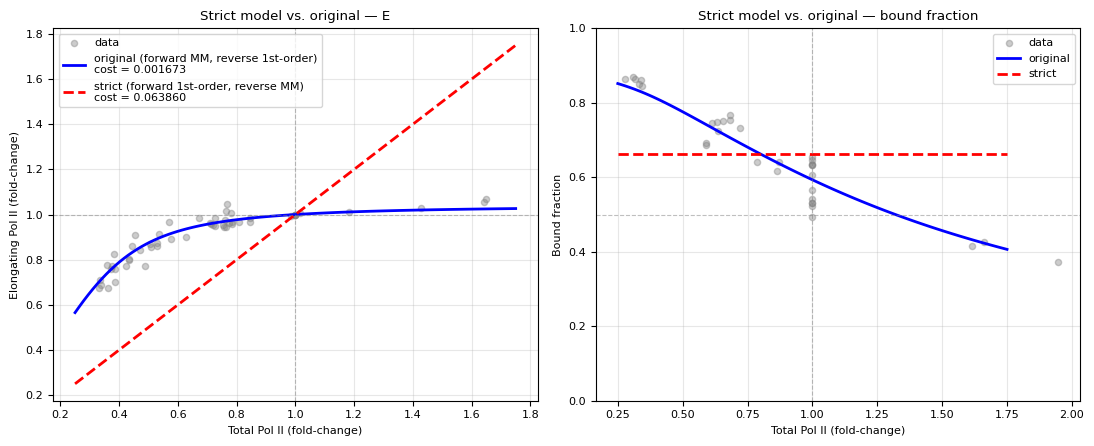

In [10]:
# Visualise: how well does the strict model match the data?
if best_strict is not None:
    full = list(best_strict.x[:4]) + [1.0, best_strict.x[4]]
    T_plot = np.linspace(0.25, 1.75, 100)

    strict_E, strict_P = [], []
    base_s = get_ss_strict(1.0, full)["solution"]
    for T in T_plot:
        r = get_ss_strict(T, full)
        if r["converged"]:
            strict_P.append(r["solution"][1])
            strict_E.append(r["solution"][2])
        else:
            strict_P.append(np.nan)
            strict_E.append(np.nan)
    strict_E = np.array(strict_E)
    strict_P = np.array(strict_P)

    # Original model for reference
    params_csv = pd.read_csv("buffering_params.csv")
    params_orig = params_csv["value"].values  # [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]

    # Compute original model cost
    orig_model_cost = compute_original_cost(params_orig)

    orig_E, orig_P = [], []
    base_o = get_ss_orig(1.0, params_orig)["solution"]
    for T in T_plot:
        r = get_ss_orig(T, params_orig)
        if r["converged"]:
            orig_P.append(r["solution"][1])
            orig_E.append(r["solution"][2])
        else:
            orig_P.append(np.nan)
            orig_E.append(np.nan)
    orig_E = np.array(orig_E)
    orig_P = np.array(orig_P)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # E fold-change
    axes[0].scatter(T_E_fc, E_fc_data, alpha=0.4, color="grey", s=20, label="data")
    axes[0].plot(
        T_plot,
        orig_E / base_o[2],
        "b-",
        lw=2,
        label=f"original (forward MM, reverse 1st-order)\ncost = {orig_model_cost:.6f}",
    )
    axes[0].plot(
        T_plot,
        strict_E / base_s[2],
        "r--",
        lw=2,
        label=f"strict (forward 1st-order, reverse MM)\ncost = {best_strict.fun:.6f}",
    )
    axes[0].axhline(1, color="grey", ls="--", alpha=0.5, lw=0.8)
    axes[0].axvline(1, color="grey", ls="--", alpha=0.5, lw=0.8)
    axes[0].set_xlabel("Total Pol II (fold-change)")
    axes[0].set_ylabel("Elongating Pol II (fold-change)")
    axes[0].set_title("Strict model vs. original — E")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    # Bound fraction
    axes[1].scatter(
        T_bound_fraction,
        bound_fraction_data,
        alpha=0.4,
        color="grey",
        s=20,
        label="data",
    )
    axes[1].plot(T_plot, (orig_P + orig_E) / T_plot, "b-", lw=2, label="original")
    axes[1].plot(T_plot, (strict_P + strict_E) / T_plot, "r--", lw=2, label="strict")
    axes[1].axhline(0.5, color="grey", ls="--", alpha=0.5, lw=0.8)
    axes[1].axvline(1, color="grey", ls="--", alpha=0.5, lw=0.8)
    axes[1].set_xlabel("Total Pol II (fold-change)")
    axes[1].set_ylabel("Bound fraction")
    axes[1].set_title("Strict model vs. original — bound fraction")
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()